Configuração e Importações

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

import warnings
warnings.filterwarnings('ignore')

Carga de Dados

In [11]:
# O caminho '../' sobe um nível para sair de 'notebooks' e entrar em 'data'
df = pd.read_csv('../data/water_potability.csv')

print(f"Dimensões do dataset: {df.shape}")
df.head()

Dimensões do dataset: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


Diagnóstico de Dados Faltantes e Tipos

--- Informações Gerais ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB

--- Dados Faltantes ---
ph                 491
Sulfate            781
Trihalomethanes    162
dtype: int64

--- Média das variáveis com nulos agrupadas por Potabilidade ---
                  ph    Sulfate  Trihalomethanes
Potability                              

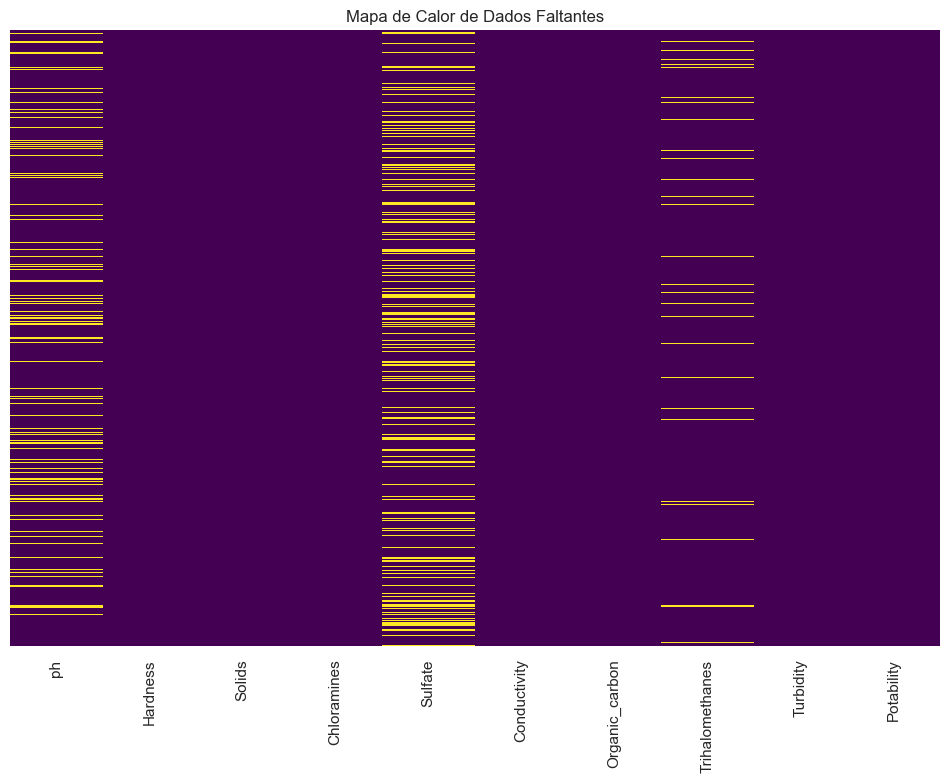

In [12]:
print("--- Informações Gerais ---")
df.info()

print("\n--- Dados Faltantes ---")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

# Analisando a média por classe para imputação estratégica
print("\n--- Média das variáveis com nulos agrupadas por Potabilidade ---")
print(df.groupby('Potability')[['ph', 'Sulfate', 'Trihalomethanes']].mean())

# Visualizando os nulos
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Dados Faltantes')
plt.show()

Análise do Alvo (Target)

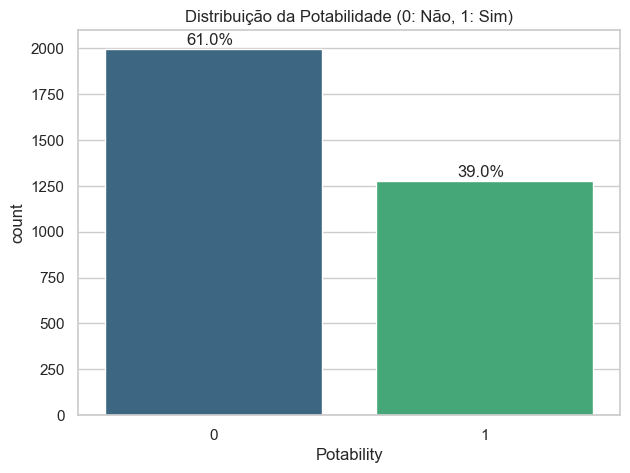

In [13]:
# Verificar se as classes estão desbalanceadas
plt.figure(figsize=(7,5))
ax = sns.countplot(x='Potability', data=df, palette='viridis')
plt.title('Distribuição da Potabilidade (0: Não, 1: Sim)')

# Adicionando porcentagens
for p in ax.patches:
    ax.annotate(f'{100 * p.get_height() / len(df):.1f}%', (p.get_x() + 0.3, p.get_height() + 20))
plt.show()

Distribuição das Variáveis Numéricas

Quantidade de Outliers por coluna (Método IQR):
Hardness           83
Chloramines        61
Solids             47
ph                 46
Sulfate            41
Trihalomethanes    33
Organic_carbon     25
Turbidity          19
Conductivity       11
Potability          0
dtype: int64


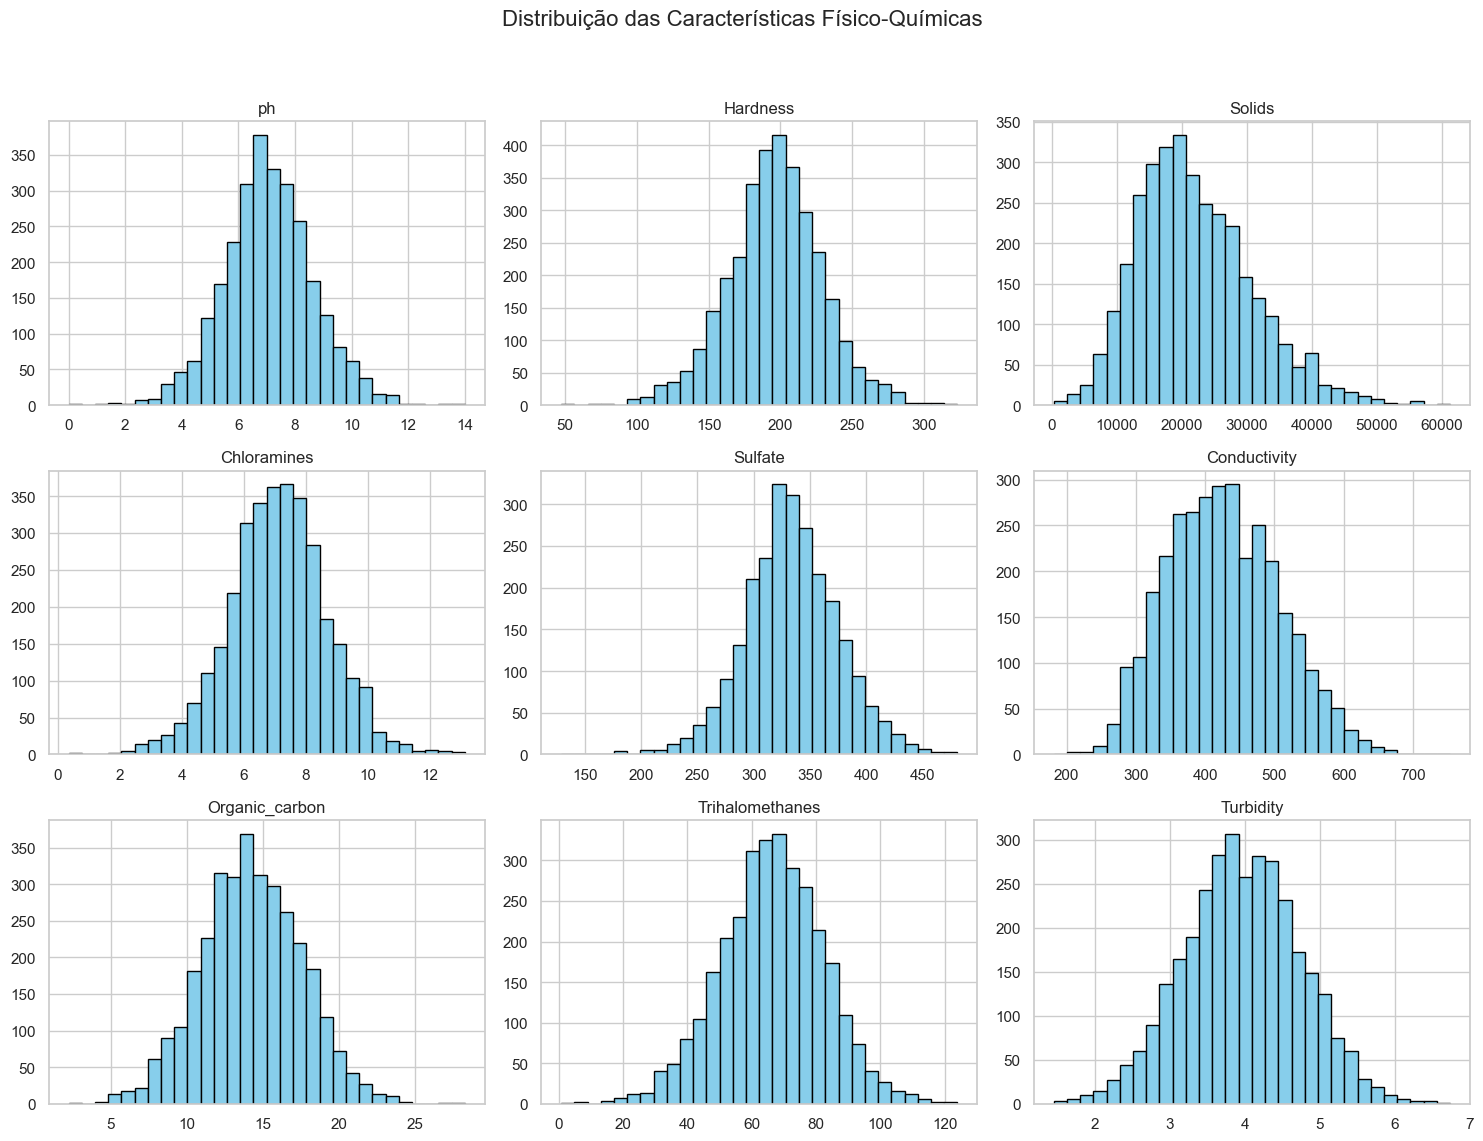

In [14]:
# Identificação de Outliers sugerida para decidir sobre o Scaler
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()

print("Quantidade de Outliers por coluna (Método IQR):")
print(outliers.sort_values(ascending=False))

# Histogramas para entender a dispersão e outliers
df.drop('Potability', axis=1).hist(bins=30, figsize=(15, 12), color='skyblue', edgecolor='black')
plt.suptitle('Distribuição das Características Físico-Químicas', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Correlação e Relações Lineares

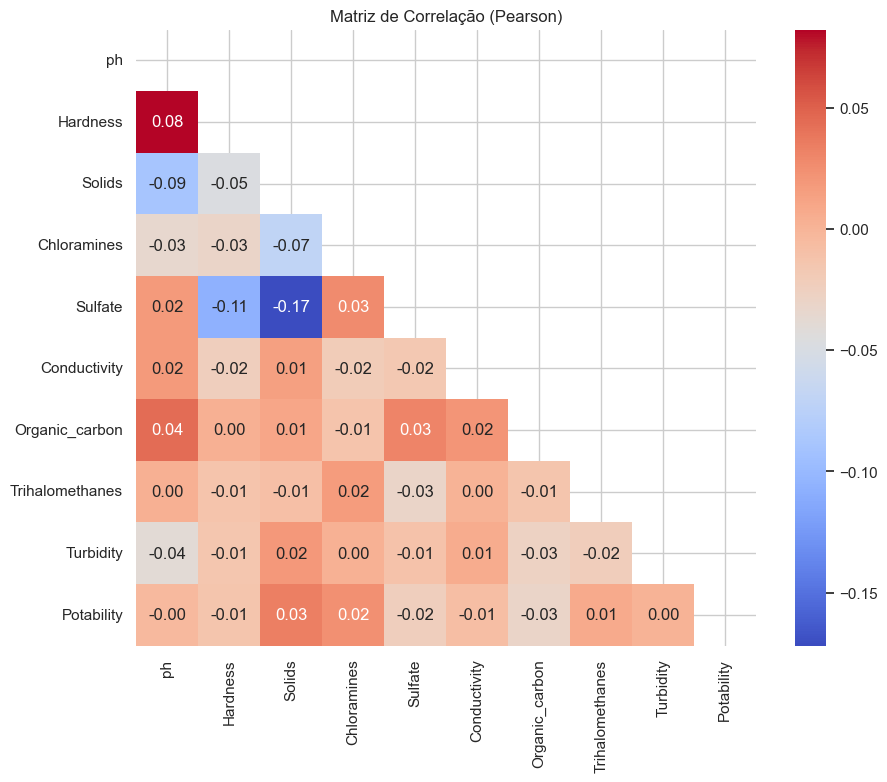

In [15]:
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação (Pearson)')
plt.show()

Análise Comparativa (Boxplots)

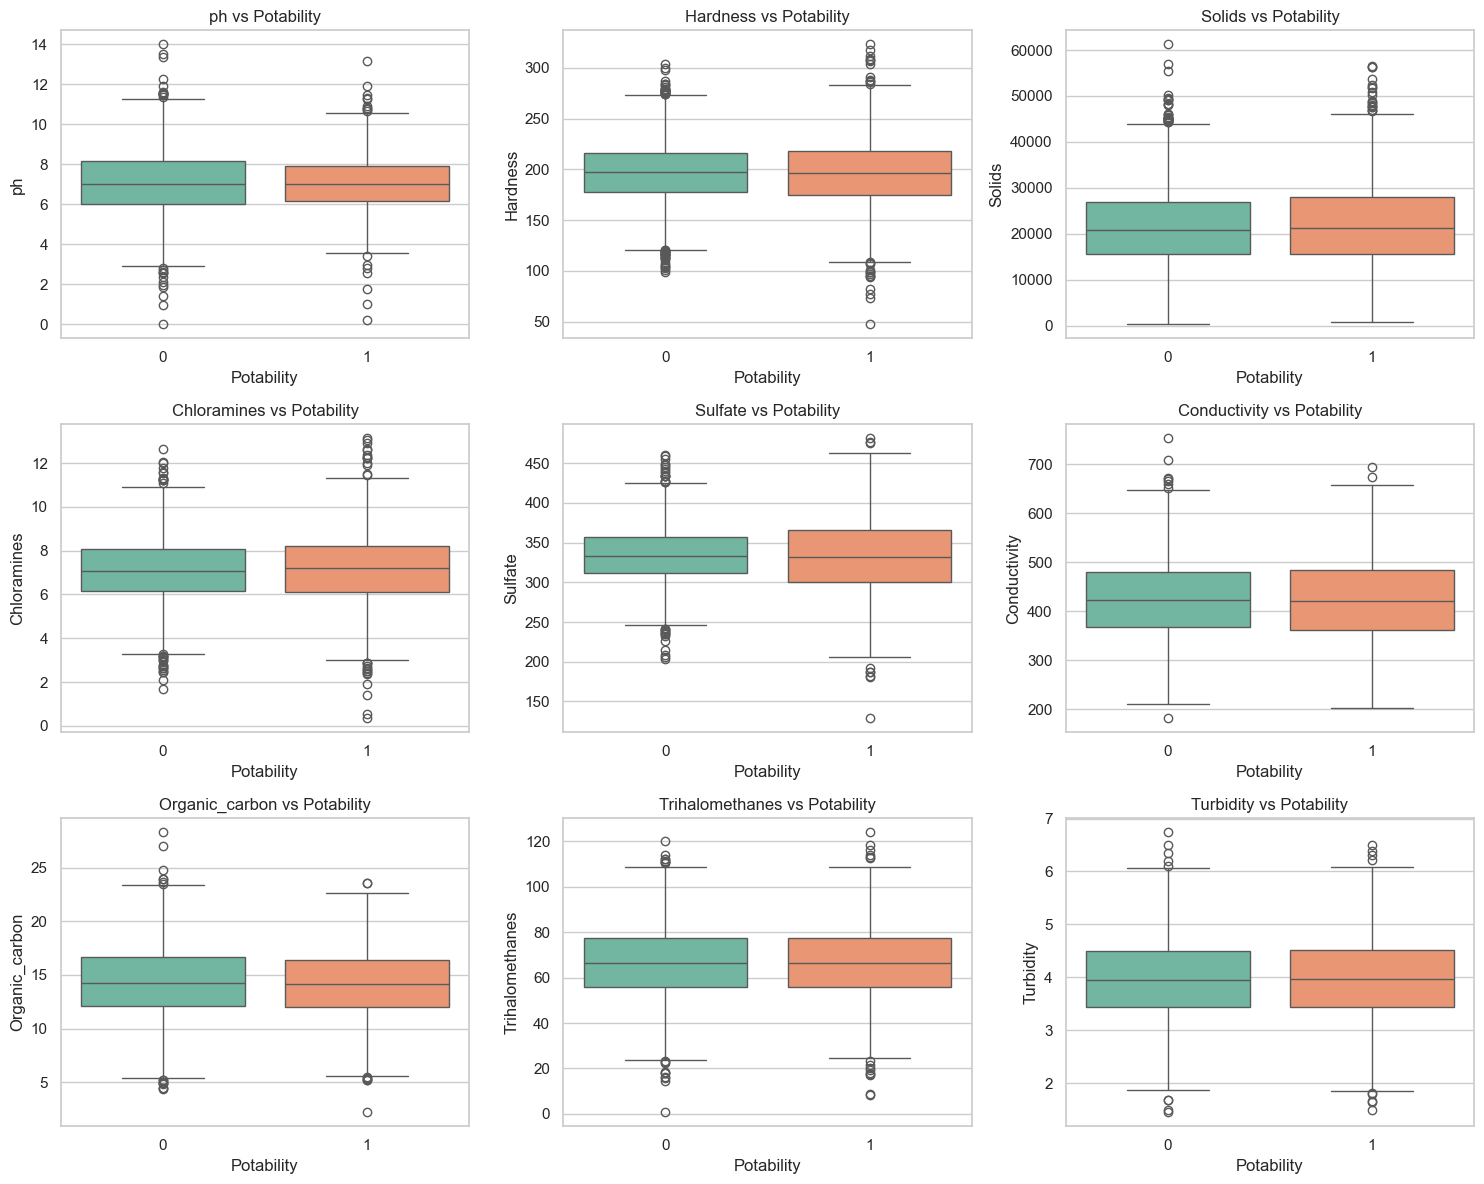

In [16]:
# Esta etapa é crucial para ver se alguma variável separa bem as classes sozinha
features = df.columns[:-1]
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x='Potability', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Potability')

plt.tight_layout()
plt.show()